In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
dataset = load_dataset("stanfordnlp/imdb")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

c:\Users\pamge\OneDrive\Desktop\clasificador-reseñas-ia\sentiment_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pamge\.cache\huggingface\hub\datasets--stanfordnlp--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
print("=== EJEMPLO===")
print(dataset["train"][0]["text"][:500])
print("\nLabel:", "Positivo ✅" if dataset["train"][0]["label"] == 1 else "Negativo ❌")

print("\n=== EJEMPLO ===")
print(dataset["train"][1]["text"][:500])
print("\nLabel:", "Positivo ✅" if dataset["train"][1]["label"] == 1 else "Negativo ❌")

=== EJEMPLO===
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Label: Negativo ❌

=== EJEMPLO ===
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, because they don't e

In [5]:
print("📊 TAMAÑO DEL DATASET")
print(f"Train:  {len(dataset['train'])} reseñas")
print(f"Test:   {len(dataset['test'])} reseñas")
print(f"Total:  {len(dataset['train']) + len(dataset['test'])} reseñas")

📊 TAMAÑO DEL DATASET
Train:  25000 reseñas
Test:   25000 reseñas
Total:  50000 reseñas


C:\Users\pamge\AppData\Local\Temp\ipykernel_25148\3876722279.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sentiment", data=train_df, palette=["#e74c3c", "#2ecc71"])


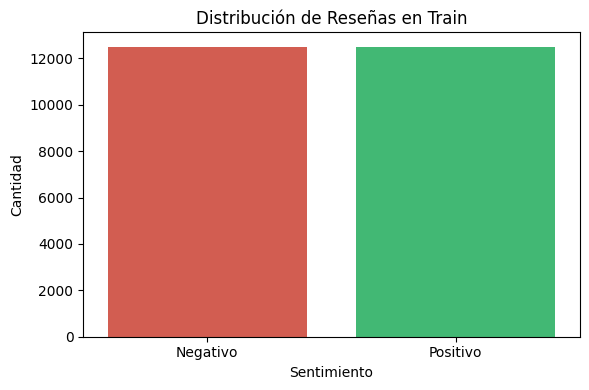

✅ Gráfica guardada


In [6]:
train_df = pd.DataFrame(dataset["train"])
train_df["sentiment"] = train_df["label"].map({0: "Negativo", 1: "Positivo"})

plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=train_df, palette=["#e74c3c", "#2ecc71"])
plt.title("Distribución de Reseñas en Train")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.savefig("distribucion_clases.png")
plt.show()
print("✅ Gráfica guardada")

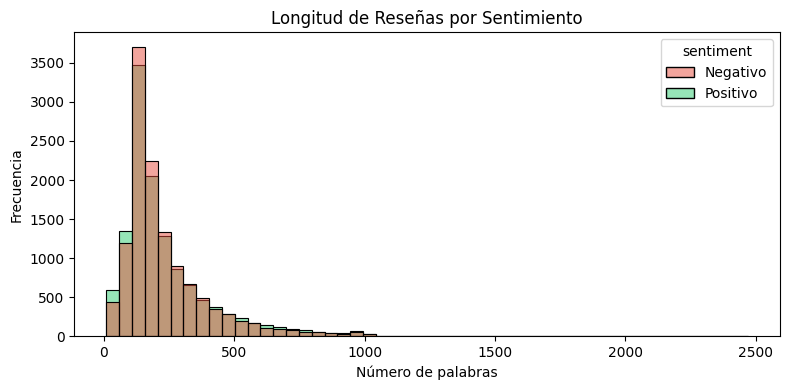


📏 Longitud promedio: 234 palabras
📏 Longitud máxima:  2470 palabras
📏 Longitud mínima:  10 palabras


In [7]:
train_df["longitud"] = train_df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(data=train_df, x="longitud", hue="sentiment", 
             bins=50, palette=["#e74c3c", "#2ecc71"])
plt.title("Longitud de Reseñas por Sentimiento")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("longitud_resenas.png")
plt.show()

print(f"\n📏 Longitud promedio: {train_df['longitud'].mean():.0f} palabras")
print(f"📏 Longitud máxima:  {train_df['longitud'].max()} palabras")
print(f"📏 Longitud mínima:  {train_df['longitud'].min()} palabras")

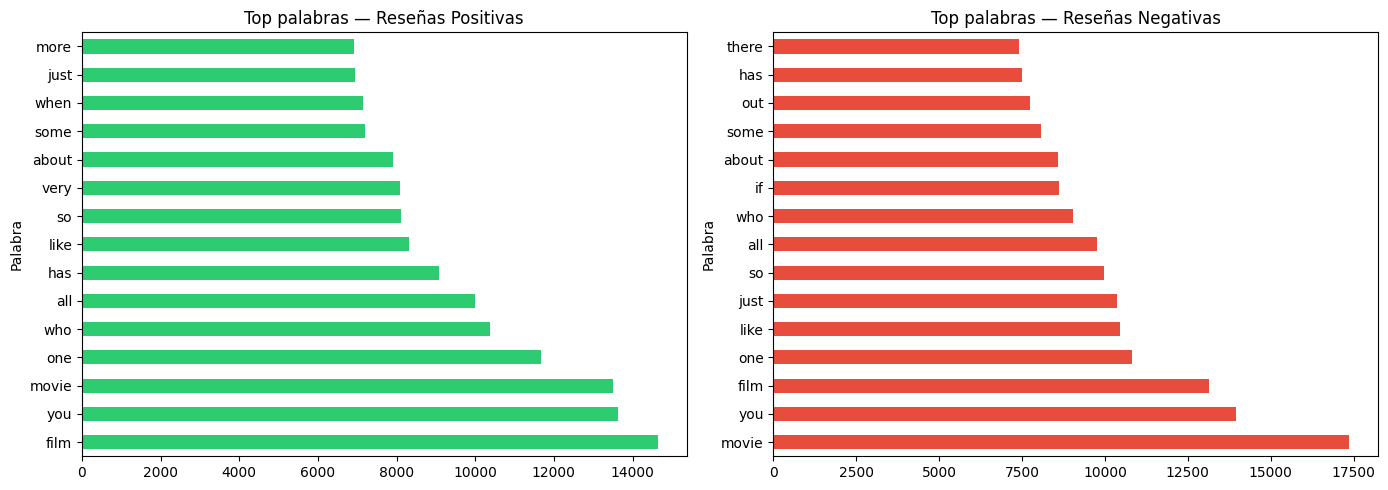

✅ Análisis completo


In [8]:
from collections import Counter

stopwords = {"the", "a", "an", "is", "it", "in", "of", "and", "to", "was", "that", "this", "i", "for", "with", "on", "are", "but", "not", "have", "as", "at", "be", "or", "from", "by", "he", "she", "they", "my", "his", "her", "its"}

positivas = train_df[train_df["label"] == 1]["text"]
negativas = train_df[train_df["label"] == 0]["text"]

def top_words(series, n=15):
    words = " ".join(series).lower().split()
    words = [w for w in words if w not in stopwords and w.isalpha()]
    return Counter(words).most_common(n)

top_pos = top_words(positivas)
top_neg = top_words(negativas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.DataFrame(top_pos, columns=["Palabra", "Frecuencia"]).plot(
    kind="barh", x="Palabra", y="Frecuencia", ax=axes[0], 
    color="#2ecc71", legend=False)
axes[0].set_title("Top palabras — Reseñas Positivas")

pd.DataFrame(top_neg, columns=["Palabra", "Frecuencia"]).plot(
    kind="barh", x="Palabra", y="Frecuencia", ax=axes[1], 
    color="#e74c3c", legend=False)
axes[1].set_title("Top palabras — Reseñas Negativas")

plt.tight_layout()
plt.savefig("palabras_comunes.png")
plt.show()
print("✅ Análisis completo")